

# Loan Default Probability 

The goal of this case study is to build a machine learning model to predict the probability that a loan will default.

__Contributors:__ 
 
Elyazid BENKHADRA  
Carla CATELAN   
Ndèye Arame MBENGUE   
Kader SORO     

## Overview

* [1. Problem Definition](#0)
* [2. Getting Started - Load Libraries and Dataset](#1)
    * [2.1. Load Libraries](#1.1)    
    * [2.2. Load Dataset](#1.2)
* [3. Data Preparation and Feature Selection](#2)
    * [3.1. Preparing the predicted variable](#2.1)    
    * [3.2. Feature Selection-Limit the Feature Space](#2.2)
        * [3.2.1.  Features elimination by significant missing values ](#2.2.1)
        * [3.2.2.  Features elimination based on the intutiveness](#2.2.2)
        * [3.2.3.  Features elimination based on the correlation](#2.2.3)   
* [4. Feature Engineering and Exploratory Analysis](#3)
    * [4.1 Feature Analysis and Exploration](#3.1)
        * [4.1.1. Analysing the categorical features](#3.1.1)
        * [4.1.2  Analysing the continuous features ](#3.1.2) 
    * [4.2.Encoding Categorical Data](#3.2)
    * [4.3.Sampling Data](#3.3)    
* [5.Evaluate Algorithms and Models](#4)        
    * [5.1. Train/Test Split](#4.1)
    * [5.2. Test Options and Evaluation Metrics](#4.2)
    * [5.3. Compare Models and Algorithms](#4.3)
* [6. Model Tuning and Grid Search](#5)  
* [7. Finalize the Model](#6)  
    * [7.1. Results on test dataset](#6.1)
    * [7.1. Variable Intuition/Feature Selection](#6.2) 
    * [7.3. Save model for later use](#6.3)


<a id='0'></a>
# 1. Problem Definition

Our aim is to analyze data for loans through 2007-2017 from Lending Club available on Kaggle. The dataset contains 100,000 loans and 151 variables among which one is describing the loan status. The predicted variable is “Charge-Off”. A charge-off is a debt that a creditor has given up trying to collect on after missed payments for several months. We want a model that can predict charge-off.

<a id='1'></a>
# 2. Getting Started - Loading the data and python packages

## 2.1. Loading the libraries needed

In [ ]:
# Libraries Importation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import math
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown


# Importing necessary libraries for model evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, roc_curve, auc, roc_auc_score, make_scorer
)

from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance



# Disable the warnings
import warnings
warnings.filterwarnings('ignore')

: 

<a id='1.2'></a>
## 2.2. Loading the Data

In [267]:
# Loading the data
dataset = pd.read_csv('LoansData_sample.csv.gz', compression='gzip', encoding='utf-8')

### Examine the properties of the data frame

In [268]:
# Data head
dataset.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,0,38098114,NaN,15000.0,15000.0,15000.0,60 months,12.39,336.64,C,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,1,36805548,NaN,10400.0,10400.0,10400.0,36 months,6.99,321.08,A,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,2,37842129,NaN,21425.0,21425.0,21425.0,60 months,15.59,516.36,D,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,3,37612354,NaN,12800.0,12800.0,12800.0,60 months,17.14,319.08,D,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,4,37662224,NaN,7650.0,7650.0,7650.0,36 months,13.66,260.20,C,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [269]:
# Data tail
dataset.tail()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
99995,99995,22454240,NaN,8400.0,8400.0,8400.0,36 months,9.17,267.79,B,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
99996,99996,11396920,NaN,10000.0,10000.0,10000.0,36 months,12.99,336.90,C,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
99997,99997,8556176,NaN,30000.0,30000.0,30000.0,60 months,20.99,811.44,E,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
99998,99998,24023408,NaN,8475.0,8475.0,8475.0,36 months,24.99,336.92,F,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
99999,99999,24023398,NaN,25000.0,25000.0,25000.0,36 months,10.15,808.45,B,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [270]:
# Shape
dataset.shape

(100000, 151)

In [271]:
# Qualitative info
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 151 entries, Unnamed: 0 to settlement_term
dtypes: float64(115), int64(2), object(34)
memory usage: 115.2+ MB


In [272]:
# Statistical description
dataset.describe()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,100000.000000,1.000000e+05,0.0,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,...,185.0,185.000000,185.0,185.000000,152.000000,185.000000,185.000000,1290.000000,1290.000000,1290.000000
mean,49999.500000,3.029995e+07,NaN,14886.930000,14886.930000,14883.910500,13.278073,437.331824,7.468924e+04,18.769787,...,3.0,110.335568,3.0,14.037838,323.495132,8046.616541,186.563135,4768.376357,47.720519,8.265116
std,28867.657797,4.763500e+06,NaN,8504.432514,8504.432514,8502.519174,4.390210,244.317648,5.809527e+04,8.539769,...,0.0,89.266601,0.0,9.657374,267.627244,5585.653253,168.552986,3703.963945,7.046587,8.263566
min,0.000000,5.716700e+04,NaN,1000.000000,1000.000000,1000.000000,6.000000,30.420000,4.000000e+03,0.000000,...,3.0,1.470000,3.0,0.000000,4.410000,174.150000,0.040000,233.160000,0.550000,0.000000
25%,24999.750000,2.737015e+07,NaN,8000.000000,8000.000000,8000.000000,10.150000,261.640000,4.500000e+04,12.320000,...,3.0,23.760000,3.0,7.000000,63.885000,2465.360000,27.610000,1951.125000,45.000000,0.000000
50%,49999.500000,3.052556e+07,NaN,13050.000000,13050.000000,13050.000000,12.990000,380.180000,6.400000e+04,18.210000,...,3.0,96.580000,3.0,15.000000,281.580000,8049.850000,172.460000,3881.120000,45.040000,6.000000
75%,74999.250000,3.438201e+07,NaN,20000.000000,20000.000000,20000.000000,15.610000,573.320000,9.000000e+04,24.760000,...,3.0,164.750000,3.0,22.000000,481.492500,11968.940000,285.890000,6503.000000,50.000000,14.000000
max,99999.000000,3.809811e+07,NaN,35000.000000,35000.000000,35000.000000,26.060000,1408.130000,7.500000e+06,39.990000,...,3.0,382.340000,3.0,32.000000,1147.020000,21750.750000,757.420000,26751.740000,100.000000,36.000000


In [273]:
# Null values overview
dataset.isnull().sum()

Unnamed: 0                    0
id                            0
member_id                100000
loan_amnt                     0
funded_amnt                   0
                          ...  
settlement_status         98710
settlement_date           98710
settlement_amount         98710
settlement_percentage     98710
settlement_term           98710
Length: 151, dtype: int64

<a id='2'></a>
## 3. Data Preparation and Feature Selection

<a id='2.1'></a>
## 3.1. Preparing the predicted variable


### The column to predict is loan_status. Look at the values it takes and their counts.

In [274]:
# Values and count for target variable
loan_status_counts = dataset['loan_status'].value_counts()
loan_status_counts

loan_status
Fully Paid            69982
Charged Off           16156
Current               12726
Late (31-120 days)      730
In Grace Period         264
Late (16-30 days)       139
Default                   3
Name: count, dtype: int64

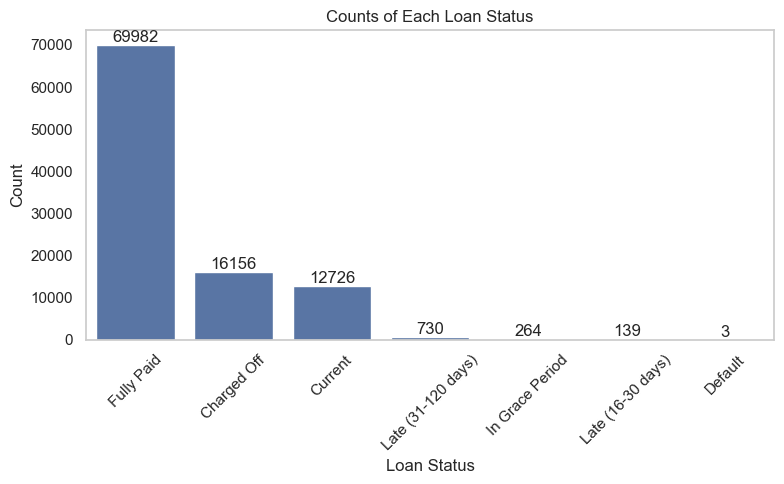

In [275]:
# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x=loan_status_counts.index, y=loan_status_counts.values)

for i, count in enumerate(loan_status_counts.values):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom')

plt.title("Counts of Each Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False)

plt.show()

In [276]:
#'Fully Paid' and 'Charged Off' repartition
loan_status_counts_binary = dataset.loc[dataset.loan_status.isin(['Fully Paid', 'Charged Off']),'loan_status'].value_counts()
binary_repartition = np.array(loan_status_counts_binary)/loan_status_counts_binary.sum()*100
print('rapartition in % [Fully Paid, Charged Off] =', binary_repartition)

rapartition in % [Fully Paid, Charged Off] = [81.24405024 18.75594976]


This is a repartition considering only the two values

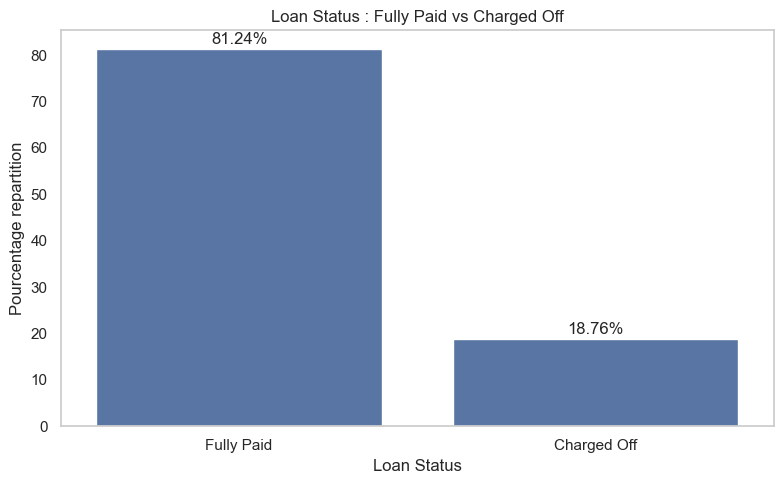

In [277]:
# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x=loan_status_counts_binary.index, y=binary_repartition)

for i, count in enumerate(binary_repartition):
    plt.text(i, count + 0.5, str(count.round(2))+'%', ha='center', va='bottom')


plt.title("Loan Status : Fully Paid vs Charged Off")
plt.xlabel("Loan Status")
plt.ylabel("Pourcentage repartition")
#plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False)
plt.show()

### Is this an unbalanced dataset ?

There’s no strict rule, but generally, a class distribution is considered unbalanced if one class makes up less than 10-20% of the total data. In our case, 'Charged Off' label constitutes 18.76% of available data. **We can safely conclude that our dataset is unbalanced**.

### Setting the labels to be 1 for Charged off else 0

In [278]:
# Setting labels at 1 and 0
dataset['charged_off'] = dataset['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)

In [279]:
# Saving original dataset
dataset_old1 = dataset.copy()

print(dataset.loan_status.head(), dataset.charged_off.head())

0     Fully Paid
1    Charged Off
2     Fully Paid
3        Current
4    Charged Off
Name: loan_status, dtype: object 0    0
1    1
2    0
3    0
4    1
Name: charged_off, dtype: int64


<a id='2.2'></a>
## 3.2. Feature Selection-Limit the Feature Space 

The full dataset has 150 features for each
loan. We’ll eliminate
features in following steps using three different approaches:
* Eliminate feature that have more than 30% missing values.
* Eliminate features that are unintuitive based on subjective judgement.
* Eliminate features with low correlation with the predicted variable.

<a id='2.2.1'></a>
### 3.2.1.  Features elimination by significant missing values

### Calculating the percentage of missing data for each feature using isnull().mean():

In [280]:
# Pourcentage of missing values for each values
columns_excluding_label = dataset.drop(columns=['loan_status'])
missing_percentage = columns_excluding_label.isnull().mean() * 100

print(missing_percentage)

Unnamed: 0                 0.00
id                         0.00
member_id                100.00
loan_amnt                  0.00
funded_amnt                0.00
                          ...  
settlement_date           98.71
settlement_amount         98.71
settlement_percentage     98.71
settlement_term           98.71
charged_off                0.00
Length: 151, dtype: float64


### Dropping the columns with more than 30% of missing data.

In [281]:
# Dropping features with too many missing data
columns_to_drop = missing_percentage[missing_percentage > 30].index
dataset = dataset.drop(columns=columns_to_drop, axis = 1)

### How large is the remaining dataset ?

In [282]:
# Shape
dataset.shape

(100000, 94)

Now our dataset is composed of 100 000 lines and 94 columns.

<a id='2.2.2'></a>
### 3.2.2.  Features elimination based on the intuitiveness

In [283]:
keep_list = ['charged_off','funded_amnt','addr_state', 'annual_inc', 'application_type', 
             'dti', 'earliest_cr_line', 'emp_length', 'emp_title', 'fico_range_high', 
             'fico_range_low', 'grade', 'home_ownership', 'id', 'initial_list_status', 
             'installment', 'int_rate', 'loan_amnt', 'loan_status', 'mort_acc', 'open_acc', 
             'pub_rec', 'pub_rec_bankruptcies', 'purpose', 'revol_bal', 'revol_util', 
             'sub_grade', 'term', 'title', 'total_acc', 'verification_status', 'zip_code',
             'last_pymnt_amnt','num_actv_rev_tl', 'mo_sin_rcnt_rev_tl_op','mo_sin_old_rev_tl_op',
             "bc_util","bc_open_to_buy","avg_cur_bal","acc_open_past_24mths" ]

### Dropping all of the features except these ones from the dataset.

In [284]:
# Dropping others features
columns_to_drop2 = dataset.drop(keep_list, axis = 1).columns
dataset = dataset.drop(columns_to_drop2, axis = 1)

### How large is the remaining dataset ?

In [285]:
# Shape
dataset.shape
print('dataset shape :', dataset.shape)
print('length of keep_list :', len(keep_list))   

dataset shape : (100000, 40)
length of keep_list : 40


We now have a dataset consisting of 100 000 lines and 40 columns.

<a id='2.2.3'></a>
### 3.2.3.  Features elimination based on the correlation

In [286]:
# All columns are not numerical 
# For the sake of computing correlations, we will convert them to numerical values using LabelEncoder
dataset_encoded = dataset.copy()
le = LabelEncoder()

for column in dataset_encoded.select_dtypes(include='object').columns:
    dataset_encoded[column] = le.fit_transform(dataset_encoded[column])

In [287]:
dataset_encoded.head()

,id,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mort_acc,num_actv_rev_tl,pub_rec_bankruptcies,charged_off
0,38098114,15000.0,15000.0,1,12.39,336.64,2,10,15833,1,...,5.0,29828.0,9525.0,4.7,244.0,1.0,0.0,4.0,0.0,0
1,36805548,10400.0,10400.0,0,6.99,321.08,0,2,29675,8,...,7.0,9536.0,7599.0,41.5,290.0,1.0,1.0,9.0,0.0,1
2,37842129,21425.0,21425.0,1,15.59,516.36,3,15,21280,6,...,4.0,4232.0,324.0,97.8,136.0,7.0,0.0,4.0,0.0,0
3,37612354,12800.0,12800.0,1,17.14,319.08,3,18,25330,1,...,2.0,32727.0,0.0,103.2,170.0,21.0,5.0,5.0,0.0,0
4,37662224,7650.0,7650.0,0,13.66,260.20,2,12,28979,10,...,6.0,5857.0,332.0,93.2,148.0,8.0,0.0,4.0,0.0,1


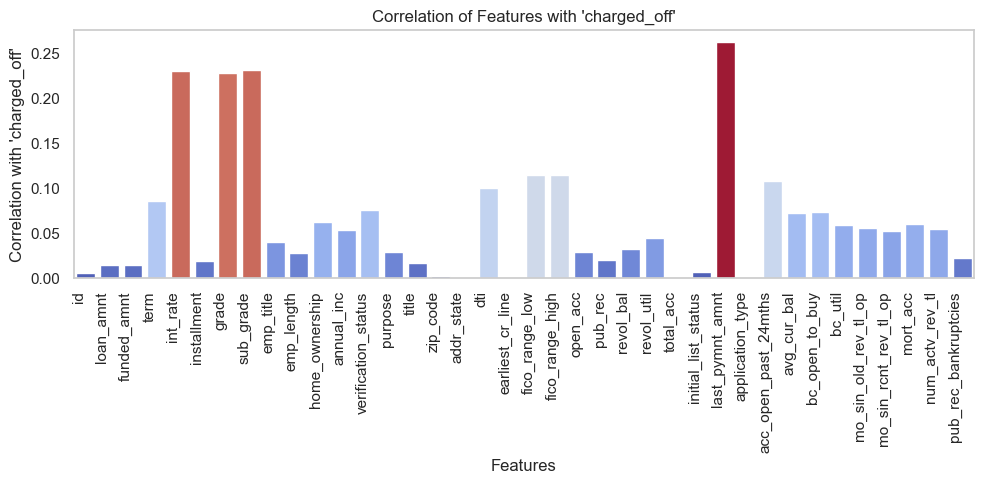

In [288]:
# Absolute correlation with charged_off
correlation_matrix = dataset_encoded.corr()
charged_off_correlation = correlation_matrix['charged_off'].drop(['charged_off', 'loan_status']).abs()

# Plotting
colors = sns.color_palette("coolwarm", as_cmap=True)
norm = plt.Normalize(charged_off_correlation.min(), charged_off_correlation.max())
bar_colors = colors(norm(charged_off_correlation.values))

plt.figure(figsize=(10, 5))
sns.barplot(x=charged_off_correlation.index, y=charged_off_correlation.values, palette=bar_colors)

plt.title("Correlation of Features with 'charged_off'")
plt.xlabel("Features")
plt.ylabel("Correlation with 'charged_off'")
plt.xticks(rotation=90, ha='right')  
plt.tight_layout()
plt.grid(False)
plt.show()

In [289]:
# Dropping low correlation columns
columns_to_drop3 = charged_off_correlation[charged_off_correlation < 0.03].index.tolist()
dataset = dataset.drop(columns_to_drop3, axis = 1)

print('numbers of columns dropped', len(columns_to_drop3))
print("")
print("Features removed due to low correlation with charged_off:")
for ele in columns_to_drop3:
    print(ele)

numbers of columns dropped 15

Features removed due to low correlation with charged_off:
id
loan_amnt
funded_amnt
installment
emp_length
purpose
title
zip_code
addr_state
earliest_cr_line
open_acc
pub_rec
total_acc
initial_list_status
pub_rec_bankruptcies


### How large is the resulting dataset ?

In [290]:
# Shape of dataset
dataset.shape

(100000, 25)

We are now left with 25 columns.

<a id='3'></a>
# 4. Feature Engineering and Exploratory Analysis

### Examining the properties of the remaining features.

In [291]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   term                   100000 non-null  object 
 1   int_rate               100000 non-null  float64
 2   grade                  100000 non-null  object 
 3   sub_grade              100000 non-null  object 
 4   emp_title              94736 non-null   object 
 5   home_ownership         100000 non-null  object 
 6   annual_inc             100000 non-null  float64
 7   verification_status    100000 non-null  object 
 8   loan_status            100000 non-null  object 
 9   dti                    100000 non-null  float64
 10  fico_range_low         100000 non-null  float64
 11  fico_range_high        100000 non-null  float64
 12  revol_bal              100000 non-null  float64
 13  revol_util             99944 non-null   float64
 14  last_pymnt_amnt        100000 non-nul

In [292]:
# Statistical description
dataset.describe()

,int_rate,annual_inc,dti,fico_range_low,fico_range_high,revol_bal,revol_util,last_pymnt_amnt,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mort_acc,num_actv_rev_tl,charged_off
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,1.000000e+05,99944.000000,100000.000000,100000.000000,100000.00000,98865.000000,98802.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000
mean,13.278073,7.468924e+04,18.769787,692.579800,696.579870,1.758806e+04,55.434985,4165.111319,4.524730,13337.70501,8956.451808,64.560022,185.826820,13.131110,1.78588,5.833610,0.161560
std,4.390210,5.809527e+04,8.539769,29.396935,29.397299,2.456089e+04,23.460328,6181.626479,3.045203,16259.76721,14048.105735,26.829802,93.434988,16.531072,2.10028,3.250546,0.368049
min,6.000000,4.000000e+03,0.000000,660.000000,664.000000,0.000000e+00,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,3.000000,0.000000,0.00000,0.000000,0.000000
25%,10.150000,4.500000e+04,12.320000,670.000000,674.000000,6.451000e+03,38.100000,348.560000,2.000000,3138.00000,1088.000000,45.200000,120.000000,4.000000,0.00000,4.000000,0.000000
50%,12.990000,6.400000e+04,18.210000,685.000000,689.000000,1.200200e+04,56.000000,784.455000,4.000000,7369.00000,3844.000000,68.700000,169.000000,8.000000,1.00000,5.000000,0.000000
75%,15.610000,9.000000e+04,24.760000,705.000000,709.000000,2.142150e+04,73.400000,6035.437500,6.000000,18362.75000,10663.000000,88.000000,234.000000,16.000000,3.00000,7.000000,0.000000
max,26.060000,7.500000e+06,39.990000,845.000000,850.000000,2.560703e+06,180.300000,36234.440000,53.000000,447433.00000,249625.000000,255.200000,818.000000,372.000000,36.00000,38.000000,1.000000


In [293]:
# Unique values
missing_count = dataset.nunique()
print('number of unique values per column :')
missing_count

number of unique values per column :


term                         2
int_rate                    58
grade                        7
sub_grade                   35
emp_title                37432
home_ownership               4
annual_inc                8895
verification_status          3
loan_status                  7
dti                       3979
fico_range_low              38
fico_range_high             38
revol_bal                37854
revol_util                1114
last_pymnt_amnt          66355
application_type             1
acc_open_past_24mths        36
avg_cur_bal              34376
bc_open_to_buy           27466
bc_util                   1182
mo_sin_old_rev_tl_op       637
mo_sin_rcnt_rev_tl_op      179
mort_acc                    28
num_actv_rev_tl             36
charged_off                  2
dtype: int64

In [294]:
# Counting missing value
missing_count = dataset.isnull().sum()
print('number of missing values per column :')
missing_count

number of missing values per column :


term                        0
int_rate                    0
grade                       0
sub_grade                   0
emp_title                5264
home_ownership              0
annual_inc                  0
verification_status         0
loan_status                 0
dti                         0
fico_range_low              0
fico_range_high             0
revol_bal                   0
revol_util                 56
last_pymnt_amnt             0
application_type            0
acc_open_past_24mths        0
avg_cur_bal                 0
bc_open_to_buy           1135
bc_util                  1198
mo_sin_old_rev_tl_op        0
mo_sin_rcnt_rev_tl_op       0
mort_acc                    0
num_actv_rev_tl             0
charged_off                 0
dtype: int64

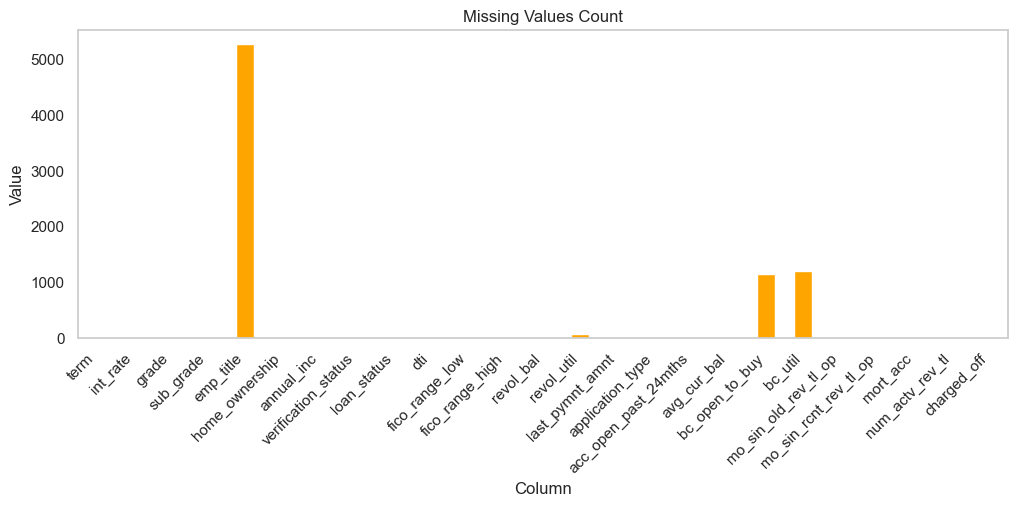

In [295]:
# Plotting
plt.figure(figsize=(12, 4))
missing_count.plot(kind='bar', color='orange')

plt.xlabel("Column")
plt.ylabel("Value")
plt.title("Missing Values Count")
plt.xticks(rotation=45, ha='right')  
plt.grid(False)
plt.show()

Overall the number of missing values is pretty low.

<a id='3.1'></a>
## 4.1 Feature Analysis and Exploration

<a id='3.1.1'></a>
### 4.1.1. Analysing the categorical features 

### Listing the categorical features and taking a decision on what to do with them 

In [296]:
# Listing categorical features
list_categorical = dataset.select_dtypes(include=['object', 'category']).columns
print('Below the list of categorical features :')
for ele in list_categorical:
    print(ele)

Below the list of categorical features :
term
grade
sub_grade
emp_title
home_ownership
verification_status
loan_status
application_type


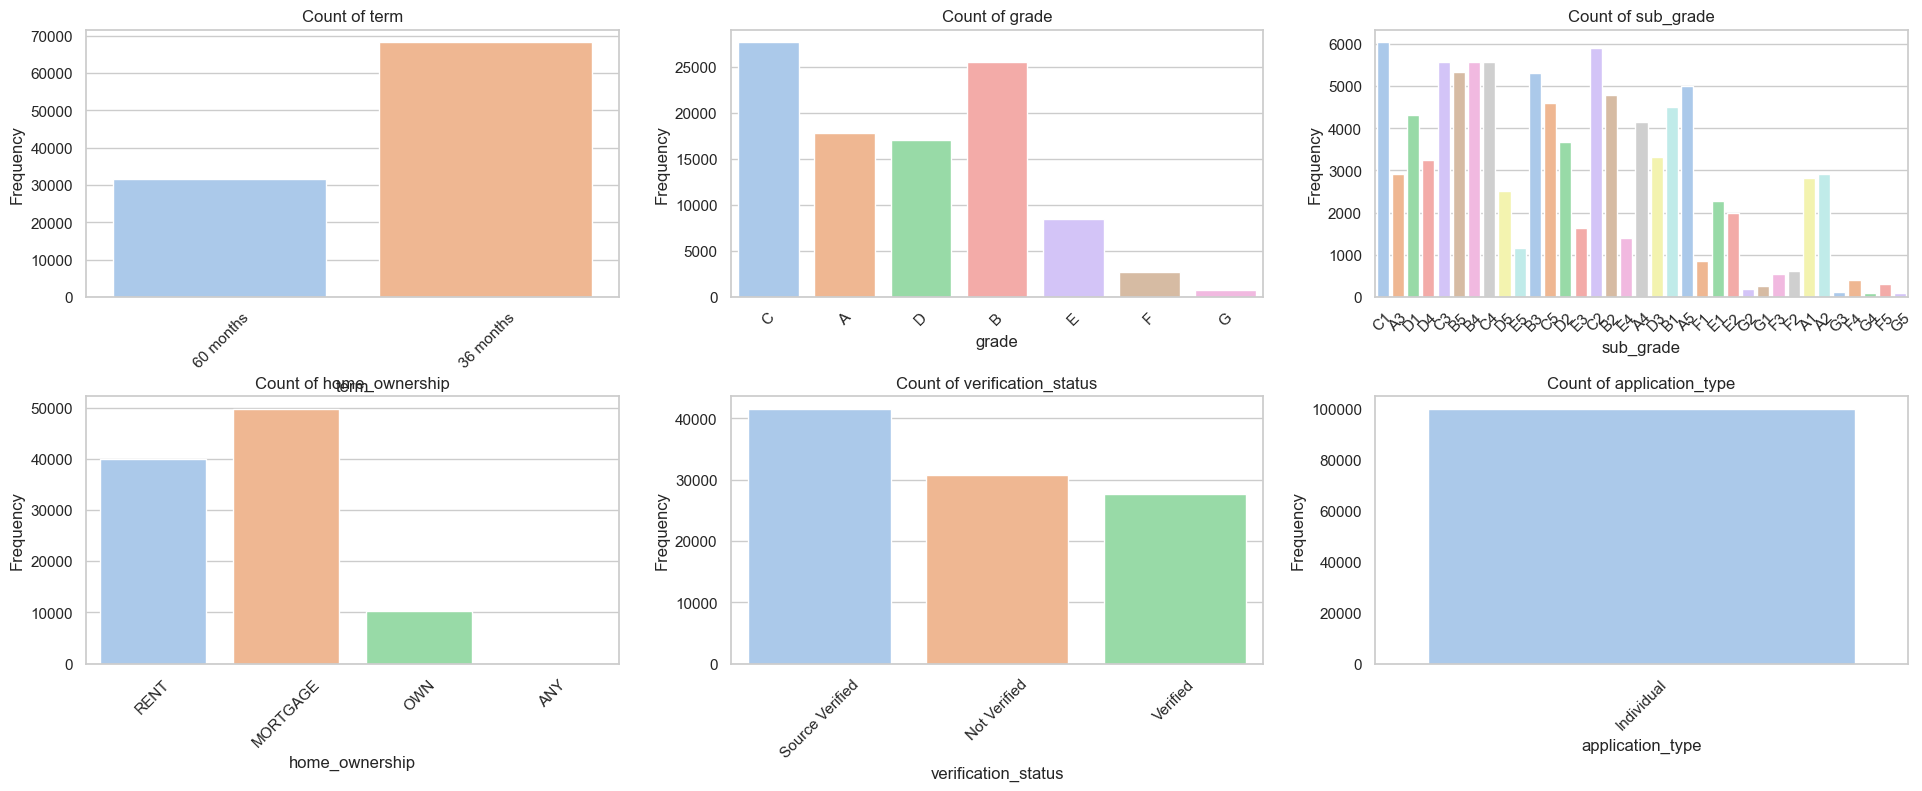

In [297]:
# Checking distribution of the categorical features
#'emp_title' has to many unique value to be plot and loan_status irrelevant

dataset_categorical = dataset.drop(['emp_title', 'loan_status'], axis=1)
list_categorical = list_categorical.drop(['emp_title', 'loan_status'])

total_categorical = list_categorical
cols = 3
rows = math.ceil(len(total_categorical) / cols)

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(20, rows * 4))
fig.tight_layout(pad=4.0)
axes = axes.flatten()

for i, column in enumerate(total_categorical):
    sns.countplot(x=dataset_categorical[column], ax=axes[i], palette='pastel')
    axes[i].set_title(f"Count of {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency")
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
    
plt.grid(False)
plt.show()

### Column 'Application_type'

At this stage, it is obvious that application_type is irrelevant. It contains only one value for all the dataset which is **'individual'**. So we decide to drop that one.
We have already dropped features with the lowest correlation. There is for now no obvious reason to give up on any of the other features for now.


In [298]:
# Application_type to be dropped from dataset
dataset = dataset.drop('application_type', axis=1)

### Column 'Emp_title'

What about 'emp_title'?

- It has the highest number of missing values: 5,264.
- It represents different job titles, with a total of 37,432 unique values.
- Its correlation with the target is 4.06%.

This feature has the highest number of missing values, and inferring it would be particularly challenging given the high number of unique categories. Additionally, it shows a very low correlation with the target. Therefore, we have decided to drop it.

In [299]:
# Emp_title to be dropped from dataset
dataset = dataset.drop('emp_title', axis=1)

In [300]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   term                   100000 non-null  object 
 1   int_rate               100000 non-null  float64
 2   grade                  100000 non-null  object 
 3   sub_grade              100000 non-null  object 
 4   home_ownership         100000 non-null  object 
 5   annual_inc             100000 non-null  float64
 6   verification_status    100000 non-null  object 
 7   loan_status            100000 non-null  object 
 8   dti                    100000 non-null  float64
 9   fico_range_low         100000 non-null  float64
 10  fico_range_high        100000 non-null  float64
 11  revol_bal              100000 non-null  float64
 12  revol_util             99944 non-null   float64
 13  last_pymnt_amnt        100000 non-null  float64
 14  acc_open_past_24mths   100000 non-nul

### Column 'Term'

In [301]:
dataset.term

0         60 months
1         36 months
2         60 months
3         60 months
4         36 months
            ...    
99995     36 months
99996     36 months
99997     60 months
99998     36 months
99999     36 months
Name: term, Length: 100000, dtype: object

In [302]:
# Converting term to numerical feature
# Map the binary categories to 0 and 1
dataset['term'] = dataset['term'].map({' 36 months': 0, ' 60 months': 1})

We choose the map '36 months' to 0 and '60 months' to 1 so that the **ordinal information** is preserved.  
The lenght of the loan may prove to be of importance.

In [303]:
dataset.term

0        1
1        0
2        1
3        1
4        0
        ..
99995    0
99996    0
99997    1
99998    0
99999    0
Name: term, Length: 100000, dtype: int64

### Column 'Emp_length'

### Deciding if we want to do anything to emp_length

Previously, we found that the correlation of 'emp_length' was below 3%, so this feature was dropped.

To compute correlations, we converted categorical features to numerical features using 'LabelEncoder', resulting in a fully numerical DataFrame stored in 'dataset_encoded'.

Let's take a closer look.

In [304]:
# Dataset_old1 is our original dataframe value_counts
dataset_old1.emp_length.value_counts()

emp_length
10+ years    33515
2 years       8838
< 1 year      8009
3 years       7797
1 year        6277
4 years       6000
7 years       5337
5 years       5232
8 years       5012
6 years       4708
9 years       4016
Name: count, dtype: int64

In [305]:
# Numerical dataframe value_counts
dataset_encoded.emp_length.value_counts()

emp_length
1     33515
2      8838
10     8009
3      7797
0      6277
4      6000
7      5337
11     5259
5      5232
8      5012
6      4708
9      4016
Name: count, dtype: int64

'emp_length' represents the length of employment, which clearly contains ordinal information. Generally, the longer someone has held a job, the more likely they are to have the financial stability to repay a loan.

Previously, when encoding this feature, the ordinal importance was not accurately accounted for. This is evident when comparing the value counts in the original DataFrame to those in the encoded DataFrame.

To achieve a more accurate correlation, we should properly map the categories to reflect their ordinal nature.

In [306]:
# New dataframe
charged_off_array = dataset_old1['charged_off']
emp_length_array = dataset_old1['emp_length']

new_correl_df = pd.DataFrame({
        'charged_off' : charged_off_array,
        'emp_length' : emp_length_array
    })

In [307]:
#emp_length list
emp_length_values = list(emp_length_array.dropna().unique())

# Mapping list
mapping_values = [11, 8, 6, 0, 2, 9, 7, 5, 3, 1, 4]

# Mapping feature values
mapping_dict = dict(zip(emp_length_values, mapping_values))

print('below the mapping dictionnary :')
mapping_dict

below the mapping dictionnary :


{'10+ years': 11,
 '8 years': 8,
 '6 years': 6,
 '< 1 year': 0,
 '2 years': 2,
 '9 years': 9,
 '7 years': 7,
 '5 years': 5,
 '3 years': 3,
 '1 year': 1,
 '4 years': 4}

In [308]:
# Applying to dataframe
new_correl_df['emp_length'] = new_correl_df['emp_length'].map(mapping_dict)
new_correl_df.head()

,charged_off,emp_length
0,0,11.0
1,1,8.0
2,0,6.0
3,0,11.0
4,1,0.0


In [309]:
# Computing correlation
new_correl_matrix = new_correl_df.corr()
print('Correlation matrix')
new_correl_matrix*100

Correlation matrix


,charged_off,emp_length
charged_off,100.000000,-1.270119
emp_length,-1.270119,100.000000


Odly, it does not seems to improve the correlation to remap the features values more accuraltely. 

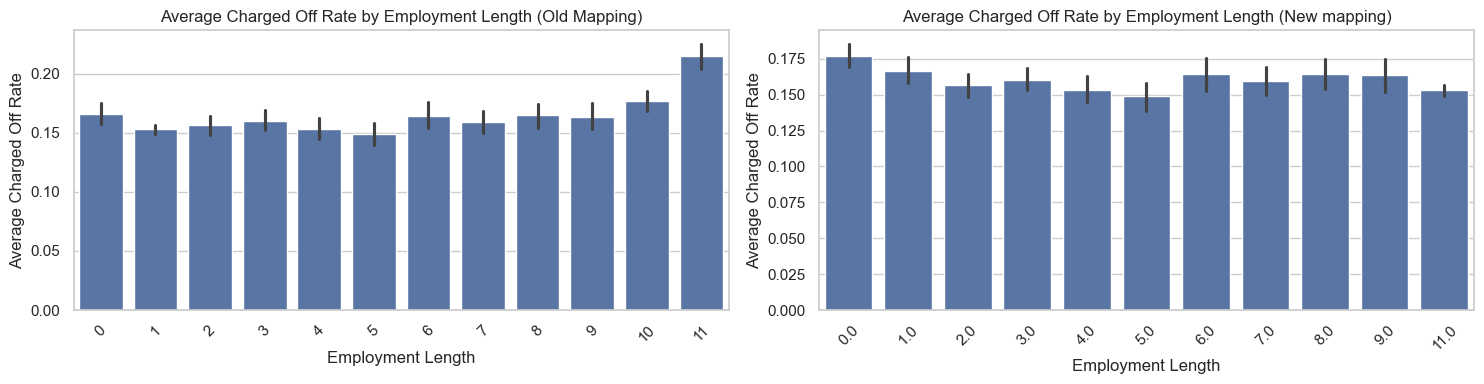

In [310]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Plotting for dataset_encoded on the first subplot
sns.barplot(x='emp_length', y='charged_off', data=dataset_encoded, estimator=lambda x: sum(x)/len(x), ax=axes[0])
axes[0].set_title("Average Charged Off Rate by Employment Length (Old Mapping)")
axes[0].set_xlabel("Employment Length")
axes[0].set_ylabel("Average Charged Off Rate")
axes[0].tick_params(axis='x', rotation=45)

# Plotting for new_correl_df on the second subplot
sns.barplot(x='emp_length', y='charged_off', data=new_correl_df, estimator=lambda x: sum(x)/len(x), ax=axes[1])
axes[1].set_title("Average Charged Off Rate by Employment Length (New mapping)")
axes[1].set_xlabel("Employment Length")
axes[1].set_ylabel("Average Charged Off Rate")
axes[1].tick_params(axis='x', rotation=45)

# Displaying the plots
plt.tight_layout()
plt.show()


Above, we are displaying the percentage of charged-off status by employment length. The relationship appears weaker for the new, "more accurate" mapping. This seems highly counterintuitive, as employment length could be viewed as a good indicator of repayment capacity.

### Columns 'Grade' and 'Sub_grade'

### Is sub_grade worth keeping ?

In [311]:
print('number of unique values in sub_grade :', dataset.sub_grade.nunique())

number of unique values in sub_grade : 35


The sub_grade, also known as the loan subgrade, is a detailed rating within a loan grade (e.g., A1, B3) that provides finer distinctions in borrower creditworthiness, helping lenders better assess and price loan risk.

The previous correlation analysis showed that this feature has one of the highest levels of correlation with the target. The different categories convey intensity information, making the numerical conversion more intuitive.

That said, it carries exactly the same information as the grade feature. The correlation between the two is at **97.80%**. It is not a good Idea to keep both.

As sub_grade is more precise and displays a slighly higher correlation with the targer than grade, **we decide to drop grade and keep sub_grade in the dataset**.

In [312]:
# Drop grade from dataset
dataset = dataset.drop('grade', axis=1)

<a id='3.1.2'></a>
### 4.1.2. Analysing the continuous features 

### Do you want to do anything to Annual Income ?

#### Feature : Annual Income

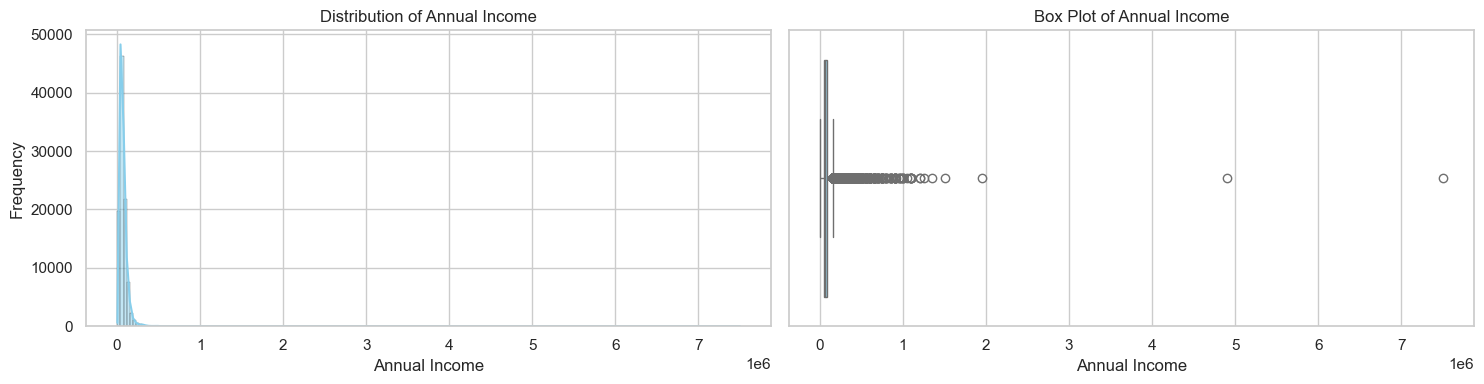

In [313]:
# Distribution plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Plotting the distribution (histogram with KDE) on the first subplot
sns.histplot(dataset['annual_inc'], bins=200, kde=True, color='skyblue', edgecolor='black', ax=axes[0])
axes[0].set_title("Distribution of Annual Income")
axes[0].set_xlabel("Annual Income")
axes[0].set_ylabel("Frequency")

# Plotting the box plot on the second subplot
sns.boxplot(x=dataset['annual_inc'], color='skyblue', ax=axes[1])
axes[1].set_title("Box Plot of Annual Income")
axes[1].set_xlabel("Annual Income")

# Displaying the plots
plt.tight_layout()
plt.show()


We can see how skewed this distribution is. For better results, we are going to normalize these feature values. Also there is the presence of outliers that need to be dealded with.

In [314]:
# Dropping any rows with NaN values in 'annual_inc' if necessary
temp = dataset.dropna(subset=['annual_inc'])

# Ranking values in ascending order
temp['annual_inc_dense_rank'] = dataset['annual_inc'].rank(method='dense')
temp

,term,int_rate,sub_grade,home_ownership,annual_inc,verification_status,loan_status,dti,fico_range_low,fico_range_high,...,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mort_acc,num_actv_rev_tl,charged_off,annual_inc_dense_rank
0,1,12.39,C1,RENT,78000.0,Source Verified,Fully Paid,12.03,750.0,754.0,...,5.0,29828.0,9525.0,4.7,244.0,1.0,0.0,4.0,0,6191.0
1,0,6.99,A3,MORTGAGE,58000.0,Not Verified,Charged Off,14.92,710.0,714.0,...,7.0,9536.0,7599.0,41.5,290.0,1.0,1.0,9.0,1,4322.0
2,1,15.59,D1,RENT,63800.0,Source Verified,Fully Paid,18.49,685.0,689.0,...,4.0,4232.0,324.0,97.8,136.0,7.0,0.0,4.0,0,4924.0
3,1,17.14,D4,MORTGAGE,125000.0,Verified,Current,8.31,665.0,669.0,...,2.0,32727.0,0.0,103.2,170.0,21.0,5.0,5.0,0,8087.0
4,0,13.66,C3,RENT,50000.0,Source Verified,Charged Off,34.81,685.0,689.0,...,6.0,5857.0,332.0,93.2,148.0,8.0,0.0,4.0,1,3366.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0,9.17,B1,MORTGAGE,91000.0,Source Verified,Fully Paid,7.78,705.0,709.0,...,2.0,25364.0,2505.0,77.2,287.0,5.0,1.0,2.0,0,6980.0
99996,0,12.99,C1,RENT,53133.0,Not Verified,Fully Paid,15.25,690.0,694.0,...,3.0,4219.0,13974.0,42.5,158.0,5.0,0.0,5.0,0,3769.0
99997,1,20.99,E4,RENT,78000.0,Verified,Current,23.75,665.0,669.0,...,5.0,20349.0,2354.0,89.4,193.0,1.0,2.0,12.0,0,6191.0
99998,0,24.99,F4,RENT,52000.0,Verified,Charged Off,17.61,660.0,664.0,...,8.0,3125.0,324.0,88.0,164.0,7.0,0.0,3.0,1,3629.0


In [315]:
dataset['annual_inc']

0         78000.0
1         58000.0
2         63800.0
3        125000.0
4         50000.0
           ...   
99995     91000.0
99996     53133.0
99997     78000.0
99998     52000.0
99999     60000.0
Name: annual_inc, Length: 100000, dtype: float64

In [316]:
# Data normalisation
scaler = StandardScaler()
dataset['annual_inc'] = scaler.fit_transform(dataset[['annual_inc']])
dataset['annual_inc'].std()

1.0000050000375005

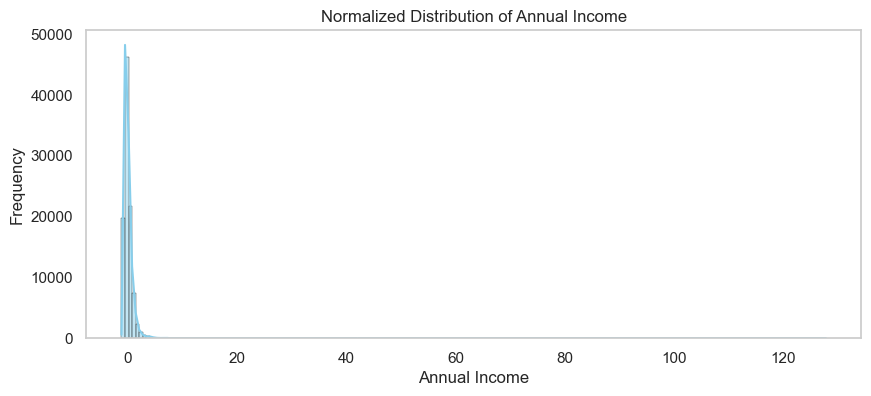

In [317]:
# Plotting after normalization
plt.figure(figsize=(10, 4))
sns.histplot(dataset['annual_inc'], bins=200, kde=True, color='skyblue', edgecolor='black')
plt.title("Normalized Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.grid(False)
plt.show()

We have the presence of big outliers that distorted the data. We are going to drop the wildest ones.

In [318]:
# Dropping the wildest outliers
# Calculating Q1, Q3 and IQR
Q1 = dataset['annual_inc'].quantile(0.25)
Q3 = dataset['annual_inc'].quantile(0.75)
IQR = Q3 - Q1

# Determining the bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering the dataset to remove outliers
dataset = dataset[(dataset['annual_inc'] >= lower_bound) & (dataset['annual_inc'] <= upper_bound)]


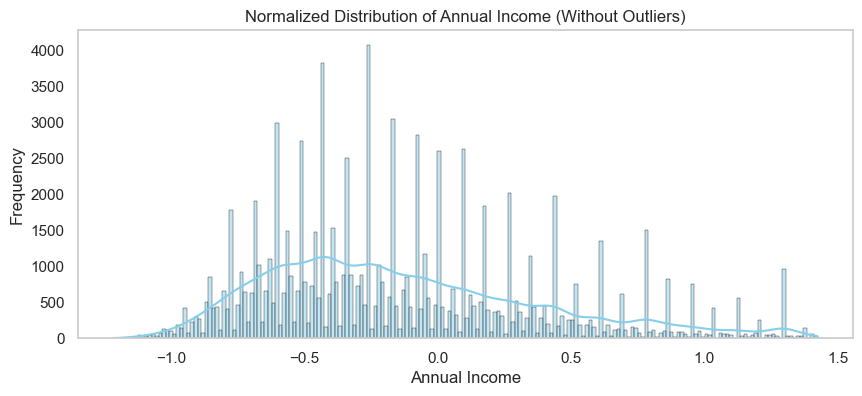

In [319]:
# Plotting the normalized distribution after outlier removal
plt.figure(figsize=(10, 4))
sns.histplot(dataset['annual_inc'], bins=200, kde=True, color='skyblue', edgecolor='black')
plt.title("Normalized Distribution of Annual Income (Without Outliers)")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.grid(False)
plt.show()

### How do you want to treat the two FICO scores ?

In [320]:
# Printing fico_range_high and fico_range_low
print('fico_range_high :', dataset.fico_range_high.unique())
print('fico_range_low :', dataset.fico_range_low.unique())

fico_range_high : [754. 714. 689. 669. 684. 704. 749. 679. 694. 664. 674. 734. 709. 719.
 779. 699. 759. 744. 729. 794. 769. 724. 739. 789. 774. 804. 799. 764.
 834. 824. 784. 809. 829. 814. 819. 839. 850. 844.]
fico_range_low : [750. 710. 685. 665. 680. 700. 745. 675. 690. 660. 670. 730. 705. 715.
 775. 695. 755. 740. 725. 790. 765. 720. 735. 785. 770. 800. 795. 760.
 830. 820. 780. 805. 825. 810. 815. 835. 845. 840.]


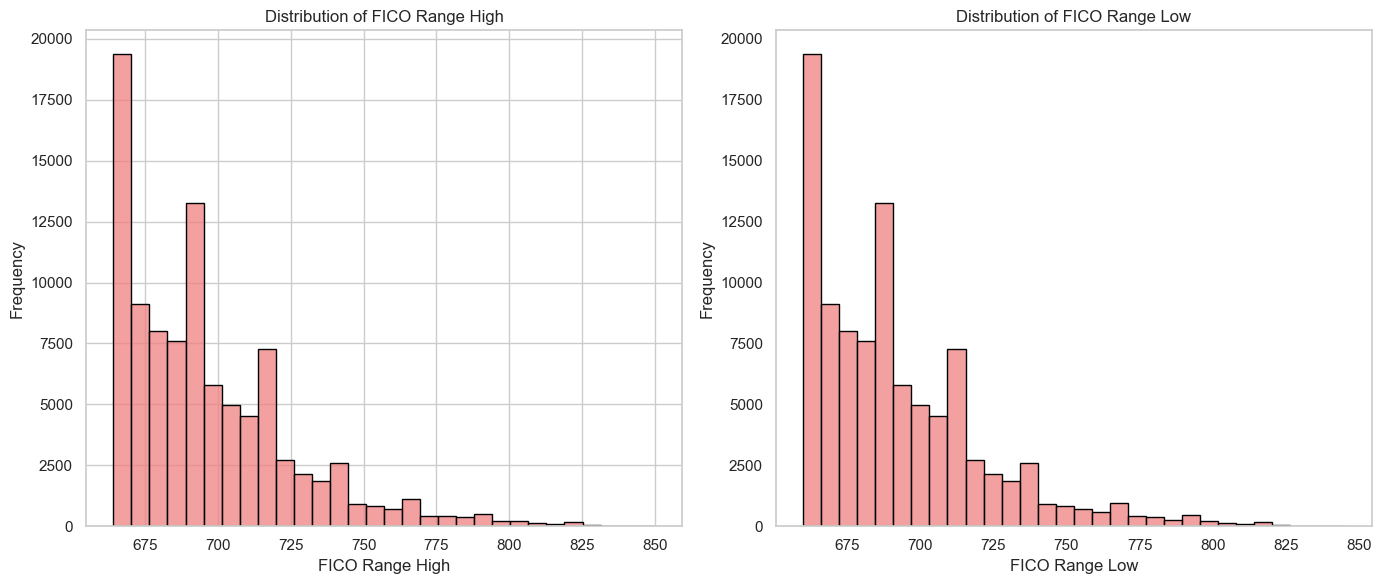

In [321]:
plt.figure(figsize=(14, 6))

# Histogram for fico_range_high
plt.subplot(1, 2, 1)
sns.histplot(dataset['fico_range_high'], bins=30, color='lightcoral', edgecolor='black')
plt.title("Distribution of FICO Range High")
plt.xlabel("FICO Range High")
plt.ylabel("Frequency")

# Histogram for fico_range_low
plt.subplot(1, 2, 2)
sns.histplot(dataset['fico_range_low'], bins=30, color='lightcoral', edgecolor='black')
plt.title("Distribution of FICO Range Low")
plt.xlabel("FICO Range Low")
plt.ylabel("Frequency")

plt.tight_layout()
plt.grid(False)
plt.show()

In [322]:
correlation_high = dataset[['fico_range_high', 'charged_off']].corr().iloc[0, 1]
correlation_low = dataset[['fico_range_low', 'charged_off']].corr().iloc[0, 1]

print(f"\nCorrelation between FICO Range High and Charged Off: {correlation_high:.2f}")
print(f"Correlation between FICO Range Low and Charged Off: {correlation_low:.2f}")



Correlation between FICO Range High and Charged Off: -0.11
Correlation between FICO Range Low and Charged Off: -0.11



Correlation between FICO Range High and FICO Range Low: 1.00


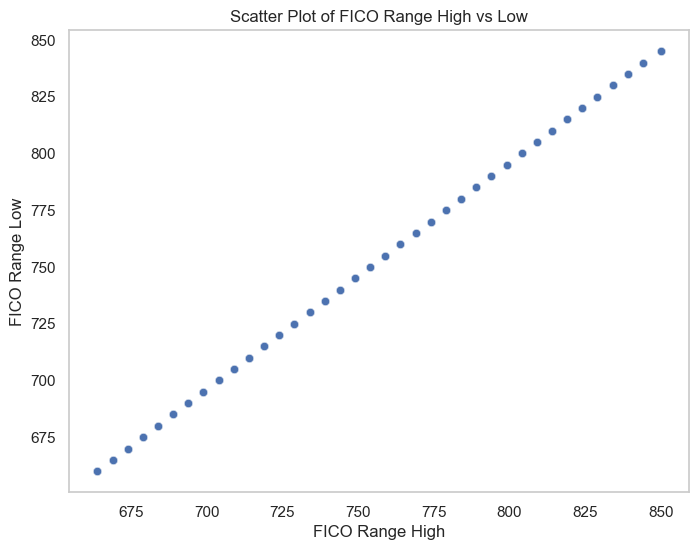

In [323]:
# Correlation between the two FICO scores
correlation_fico = dataset[['fico_range_high', 'fico_range_low']].corr().iloc[0, 1]
print(f"\nCorrelation between FICO Range High and FICO Range Low: {correlation_fico:.2f}")

# Scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
sns.scatterplot(x='fico_range_high', y='fico_range_low', data=dataset, alpha=0.6)
plt.title("Scatter Plot of FICO Range High vs Low")
plt.xlabel("FICO Range High")
plt.ylabel("FICO Range Low")
plt.grid(False)
plt.show()


The correlation between FICO Range High and FICO Range Low is 1.00, indicating that the two variables are perfectly correlated. Examining the values of both columns, we observe that the histograms are identical, with only a 4-point difference between the corresponding values.
So it is unnecessary to retain both columns in our analysis, as they provide the same information, we will drop one column. 



In [324]:
# Dropping the 'fico_range_low' column
dataset = dataset.drop(columns=['fico_range_low'])
print (dataset)

       term  int_rate sub_grade home_ownership  annual_inc  \
0         1     12.39        C1           RENT    0.056989   
1         0      6.99        A3       MORTGAGE   -0.287275   
2         1     15.59        D1           RENT   -0.187439   
3         1     17.14        D4       MORTGAGE    0.866009   
4         0     13.66        C3           RENT   -0.424981   
...     ...       ...       ...            ...         ...   
99995     0      9.17        B1       MORTGAGE    0.280760   
99996     0     12.99        C1           RENT   -0.371052   
99997     1     20.99        E4           RENT    0.056989   
99998     0     24.99        F4           RENT   -0.390554   
99999     0     10.15        B2            OWN   -0.252849   

      verification_status  loan_status    dti  fico_range_high  revol_bal  \
0         Source Verified   Fully Paid  12.03            754.0   138008.0   
1            Not Verified  Charged Off  14.92            714.0     6133.0   
2         Source Verifie

<a id='3.2'></a>
## 4.2. Encoding Categorical Data

In [325]:
# Listing categorical features
list_categorical = dataset.select_dtypes(include=['object', 'category']).columns
print('Below the list of categorical features :')
for ele in list_categorical:
    print(ele)

Below the list of categorical features :
sub_grade
home_ownership
verification_status
loan_status


In [326]:
#putting loan_status aside
list_categorical = list_categorical.drop('loan_status')

As a reminder, we have removed the 'grade' column, which duplicated information from the 'sub_grade' column. We also eliminated 'application_type' since there was only one type of application, which did not provide any additional information. Moreover, 'purpose', 'addr_state', and 'initial_list_status' were discarded due to their low correlation with 'charged off'. Therefore, we are left with only three categorical features.

In [327]:
#sub_grade values
dataset.sub_grade.unique()

array(['C1', 'A3', 'D1', 'D4', 'C3', 'B5', 'B4', 'C4', 'D5', 'E5', 'B3',
       'C5', 'D2', 'E3', 'C2', 'B2', 'E4', 'A4', 'D3', 'B1', 'A5', 'F1',
       'E1', 'E2', 'G2', 'G1', 'F3', 'F2', 'A1', 'A2', 'G3', 'F4', 'G4',
       'F5', 'G5'], dtype=object)

In [328]:
mapping_dict_subgrade = {'A1': 0, 'A2': 1, 'A3': 2, 'A4': 3, 'A5': 4,
                        'B1': 5, 'B2': 6, 'B3': 7, 'B4': 8, 'B5': 9,
                        'C1': 10, 'C2': 11, 'C3': 12, 'C4': 13, 'C5': 14,
                        'D1': 15, 'D2': 16, 'D3': 17, 'D4': 18, 'D5': 19,
                        'E1': 20, 'E2': 21, 'E3': 22, 'E4': 23, 'E5': 24,
                        'F1': 25, 'F2': 26, 'F3': 27, 'F4': 28, 'F5': 29,
                        'G1': 30, 'G2': 31, 'G3': 32, 'G4': 33, 'G5': 34}

#encoding sub_grade
dataset['sub_grade'] = dataset['sub_grade'].map(mapping_dict_subgrade)

For sub_grade, we implement a manual mapping to not loose the information contained in the order of grades.

For the other categorical features, we are going to use a LabelEncoder

In [329]:
#dropping sub_grade
list_categorical = list_categorical.drop('sub_grade')

In [330]:
# Creating a label encoder object
label = LabelEncoder()

# Encoding the categorical features
for column in list_categorical:
    dataset[column] = label.fit_transform(dataset[column])

In [331]:
dataset.loc[:,['sub_grade', 'home_ownership', 'verification_status']].head()

,sub_grade,home_ownership,verification_status
0,10,3,1
1,2,1,0
2,15,3,1
3,18,1,2
4,12,3,1


<a id='3.4'></a>
## 4.3. Sampling Data

### Creating a balanced dataset that draws 5500 rows at random from each of the two classes and combining them into a new dataframe.

We are about to randomly select data row in our dataset. Before that, let's drop all NaN values. That way, we avoid randomly selecting some NaN.


In [332]:
dataset = dataset.dropna()
dataset.shape

(94347, 21)

In [333]:
# Create a new balanced dataframe 
charged_off = dataset[dataset['loan_status'] == 'Charged Off'].sample(n=5500, random_state=37)
fully_paid = dataset[dataset['loan_status'] == 'Fully Paid'].sample(n=5500, random_state=37)

In [334]:
dataset_balanced = pd.concat([charged_off, fully_paid], axis=0)
dataset_balanced

,term,int_rate,sub_grade,home_ownership,annual_inc,verification_status,loan_status,dti,fico_range_high,revol_bal,...,last_pymnt_amnt,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mort_acc,num_actv_rev_tl,charged_off
29717,0,13.66,12,3,0.573384,0,Charged Off,11.70,669.0,23254.0,...,1041.50,8.0,1093.0,4129.0,77.8,235.0,1.0,0.0,15.0,1
36758,0,11.67,8,1,-0.407768,1,Charged Off,25.69,669.0,2819.0,...,214.87,0.0,1122.0,3281.0,83.8,216.0,73.0,0.0,6.0,1
84237,1,14.49,13,1,0.607811,2,Charged Off,19.37,689.0,78358.0,...,329.33,7.0,31328.0,6291.0,84.1,266.0,2.0,7.0,10.0,1
47904,1,14.49,13,1,0.211907,1,Charged Off,14.36,669.0,14151.0,...,319.92,6.0,10388.0,7806.0,52.4,114.0,8.0,1.0,2.0,1
30160,0,17.86,19,3,-0.823088,2,Charged Off,37.62,689.0,10456.0,...,443.82,9.0,2114.0,4745.0,37.6,88.0,16.0,0.0,7.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30141,1,14.99,14,1,0.091415,2,Fully Paid,34.49,709.0,75996.0,...,11378.30,3.0,14997.0,21546.0,68.7,200.0,15.0,2.0,8.0,0
18496,0,11.99,9,3,-0.683179,1,Fully Paid,14.33,704.0,3755.0,...,5648.10,5.0,1752.0,5459.0,39.3,56.0,1.0,0.0,3.0,0
17126,0,13.66,12,3,-0.769245,0,Fully Paid,21.52,669.0,3065.0,...,2785.03,4.0,4247.0,491.0,72.7,125.0,3.0,0.0,5.0,0
69929,0,18.24,19,1,-0.459407,1,Fully Paid,29.63,669.0,4158.0,...,4423.10,7.0,8833.0,738.0,82.0,25.0,13.0,0.0,3.0,0


In [335]:
#dropping loan_status, no more relevant
dataset_balanced = dataset_balanced.drop('loan_status', axis = 1)

In [336]:
# Check the distribution of the target variable
dataset_balanced['charged_off'].value_counts()

charged_off
1    5500
0    5500
Name: count, dtype: int64

In [337]:
# Checking the distribution of the target variable
dataset_balanced['charged_off'].value_counts()

charged_off
1    5500
0    5500
Name: count, dtype: int64

### Choosing a method to handle any NAs that may be in a column.

All NAs have been dropped before building balanced dataset.


In [338]:
dataset_balanced.isnull().sum()

term                     0
int_rate                 0
sub_grade                0
home_ownership           0
annual_inc               0
verification_status      0
dti                      0
fico_range_high          0
revol_bal                0
revol_util               0
last_pymnt_amnt          0
acc_open_past_24mths     0
avg_cur_bal              0
bc_open_to_buy           0
bc_util                  0
mo_sin_old_rev_tl_op     0
mo_sin_rcnt_rev_tl_op    0
mort_acc                 0
num_actv_rev_tl          0
charged_off              0
dtype: int64

In [339]:
dataset_balanced.shape

(11000, 20)

<a id='4'></a>
# 5. Evaluating Algorithms and Models

<a id='4.1'></a>
## 5.1. Train Test Split

### Using an 80:20 split

In [340]:
X = dataset_balanced.drop(columns=['charged_off'])
y = dataset_balanced['charged_off']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training set: {X_train.shape}, {y_train.shape}')
print(f'Test set: {X_test.shape}, {y_test.shape}')

Training set: (8800, 19), (8800,)
Test set: (2200, 19), (2200,)


<a id='4.2'></a>
## 5.2. Test Options and Evaluation Metrics


### Use K-Folds cross validation with 10 folds and 'roc-auc' as your score.

In [341]:
# Defining K-Fold cross-validation with 10 splits
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

<a id='4.3'></a>
## 5.3. Comparing Models and Algorithms

In [342]:
# List of models to use 
models = []
models.append(('LR', LogisticRegression()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('DT', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('NN', MLPClassifier()))
models.append(('AB', AdaBoostClassifier()))
models.append(('RF', RandomForestClassifier()))

# Storing model's performance
model_results = []
model_scores = {}


# Applying cross-validation on each model and evaluating them using roc_auc
for model_name, model in models:
    print(f'--- {model_name} ---')
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='roc_auc')
    mean_score = cv_scores.mean()
    model_results.append((model_name, mean_score))
    model_scores[model_name] = cv_scores
    print(f'ROC AUC scores across folds: {cv_scores}')
    print("")
    print(f'Mean ROC AUC: {mean_score:.4f}\n')

# Identifying the best model based on mean ROC AUC
best_model_name, best_score = max(model_results, key=lambda item: item[1])
print(f'Best Model: {best_model_name} with Mean ROC AUC: {best_score:.4f}')

--- LR ---
ROC AUC scores across folds: [0.89020088 0.86584641 0.87386815 0.89715856 0.87818635 0.8493174
 0.88274216 0.8559755  0.85780992 0.87680785]

Mean ROC AUC: 0.8728

--- KNN ---
ROC AUC scores across folds: [0.76891151 0.77312641 0.77583045 0.79436361 0.77701589 0.76446934
 0.78996018 0.76492131 0.80389721 0.75686725]

Mean ROC AUC: 0.7769

--- DT ---
ROC AUC scores across folds: [0.7817809  0.8079613  0.79430937 0.79543283 0.77494718 0.7738134
 0.78634704 0.81137299 0.78181818 0.79545455]

Mean ROC AUC: 0.7903

--- NB ---
ROC AUC scores across folds: [0.89475152 0.87950351 0.87467394 0.90740655 0.88585168 0.87407476
 0.89378044 0.88976699 0.8802686  0.89759298]

Mean ROC AUC: 0.8878

--- NN ---
ROC AUC scores across folds: [0.81585649 0.84555189 0.81803625 0.84704725 0.84006891 0.84636026
 0.85604006 0.87741672 0.85497934 0.85254132]

Mean ROC AUC: 0.8454

--- AB ---
ROC AUC scores across folds: [0.93559884 0.92476976 0.92182036 0.92927908 0.91427383 0.91395617
 0.91885805 0.

In [363]:
for key, value in model_scores.items():
    print(f'--key--')
    print('ROC AUC scores across folds :', value)
    print('')
    print('Mean ROC AUC: ', value.mean())

--key--
ROC AUC scores across folds : [0.89020088 0.86584641 0.87386815 0.89715856 0.87818635 0.8493174
 0.88274216 0.8559755  0.85780992 0.87680785]

Mean ROC AUC:  0.8727913188509401
--key--
ROC AUC scores across folds : [0.76891151 0.77312641 0.77583045 0.79436361 0.77701589 0.76446934
 0.78996018 0.76492131 0.80389721 0.75686725]

Mean ROC AUC:  0.7769363164249491
--key--
ROC AUC scores across folds : [0.7817809  0.8079613  0.79430937 0.79543283 0.77494718 0.7738134
 0.78634704 0.81137299 0.78181818 0.79545455]

Mean ROC AUC:  0.7903237737422574
--key--
ROC AUC scores across folds : [0.89475152 0.87950351 0.87467394 0.90740655 0.88585168 0.87407476
 0.89378044 0.88976699 0.8802686  0.89759298]

Mean ROC AUC:  0.8877670970089875
--key--
ROC AUC scores across folds : [0.81585649 0.84555189 0.81803625 0.84704725 0.84006891 0.84636026
 0.85604006 0.87741672 0.85497934 0.85254132]

Mean ROC AUC:  0.845389848335652
--key--
ROC AUC scores across folds : [0.93559884 0.92476976 0.92182036 0

### Plotting BoxPlot

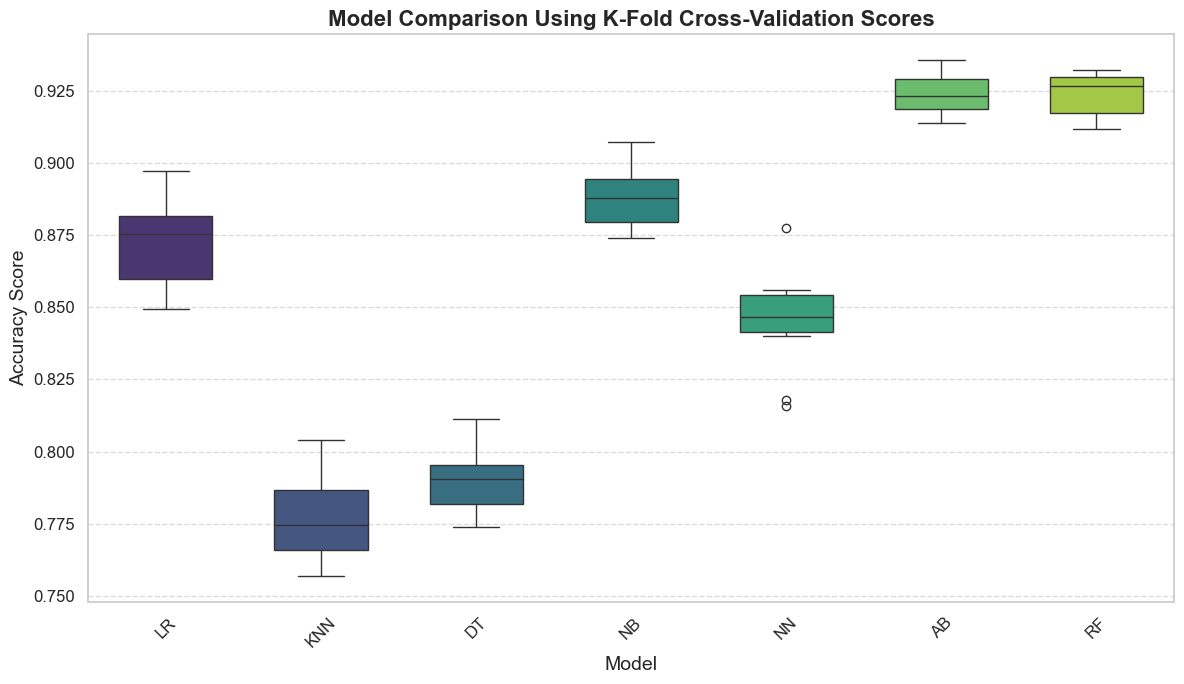

In [343]:
#plotting
scores_df = pd.DataFrame(model_scores)

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid") 
palette = sns.color_palette("viridis", len(models))

# Plotting the box plot
sns.boxplot(data=scores_df, palette=palette, width=0.6, linewidth=1)

plt.title("Model Comparison Using K-Fold Cross-Validation Scores", fontsize=16, fontweight='bold')
plt.xlabel("Model", fontsize=14)
plt.ylabel("Accuracy Score", fontsize=14)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) 

# Displaying the plot
plt.tight_layout()
plt.show()

The box plot helps us visualize the variability in cross-validation scores across folds for each model, highlighting models that are more consistent (narrower boxes) versus those with more variability (wider boxes). 

The overall level of the box tell you how well the model is doing. Based on our results, Random Forest and AdaBoost Classifier are doing better.

<a id='5'></a>
# 6. Model Tuning and Grid Search (May take some time)

Our two best models are the Random Forest and AdaBoost Classifier. Deciding which one to focus on based on our results is not straightforward.

In fact, the highest accuracy score occurrence is with AdaBoost, and this model also shows less variance. On the other hand, while it has more variance, the Random Forest model presents the highest median accuracy.

That said, we will prioritize the model with the highest median accuracy and choose the Random Forest as our base model.

Therefore, we will proceed with tuning its hyperparameters.

In [344]:
# Initializing the model
best_model = RandomForestClassifier(random_state=42)

# Defining the parameter grid
param_grid = {
    'n_estimators': [150, 200, 250],
    'max_depth': [None, 10, 12, 15],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3],
    'bootstrap': [True, False]
}

# Using Stratified K-Folds in GridSearchCV
stratified_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(estimator=best_model, param_grid=param_grid, cv=stratified_cv, scoring='roc_auc', n_jobs=-1, verbose=2, return_train_score=True)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("")
print("Best Cross-Validation Score:", grid_search.best_score_)

Fitting 3 folds for each of 216 candidates, totalling 648 fits
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time=   4.0s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time=   4.1s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time=   4.2s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   5.5s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   5.5s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   5.5s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=250; total time=   7.0s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=250; tota

Compared to other models, the Random Forest algorithm takes longer to fit. For simplicity, we decided to use 3 splits in our Grid Search implementation.   
Otherwise, it would be too computationally expensive.

In [345]:
print("Best Parameters:", grid_search.best_params_)
print("")
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'bootstrap': False, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 250}

Best Cross-Validation Score: 0.9267531842398166


<a id='6'></a>
# 7. Finalising the Model

In [346]:
# Best model with the optimal parameters found by GridSearchCV
final_model = grid_search.best_estimator_

# Fitting the final model on the entire training data
final_model.fit(X_train, y_train)


RandomForestClassifier(bootstrap=False, max_depth=10, min_samples_leaf=2,
                       n_estimators=250, random_state=42)

<a id='6.1'></a>
## 7.1. Results on the Test Dataset

Final Model Test Accuracy: 0.8345454545454546

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.77      0.82      1092
           1       0.80      0.90      0.85      1108

    accuracy                           0.83      2200
   macro avg       0.84      0.83      0.83      2200
weighted avg       0.84      0.83      0.83      2200




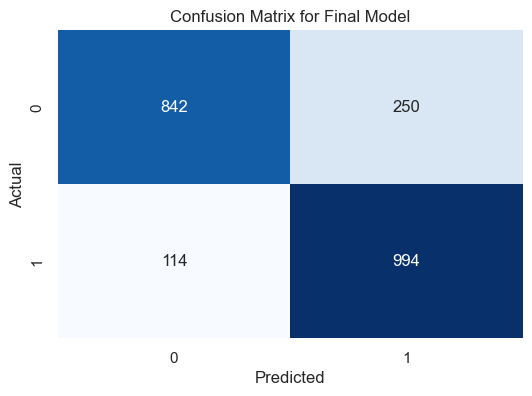

In [347]:
# Predicting on the test data
y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1] if hasattr(final_model, "predict_proba") else None


print("Final Model Test Accuracy:", accuracy_score(y_test, y_pred))
print("")

print("Classification Report:\n", classification_report(y_test, y_pred))

print("")
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix for Final Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Here we have an overview of our model performance on the out of sample dataset.

### Calculating the ROC curve for the model and its AUC

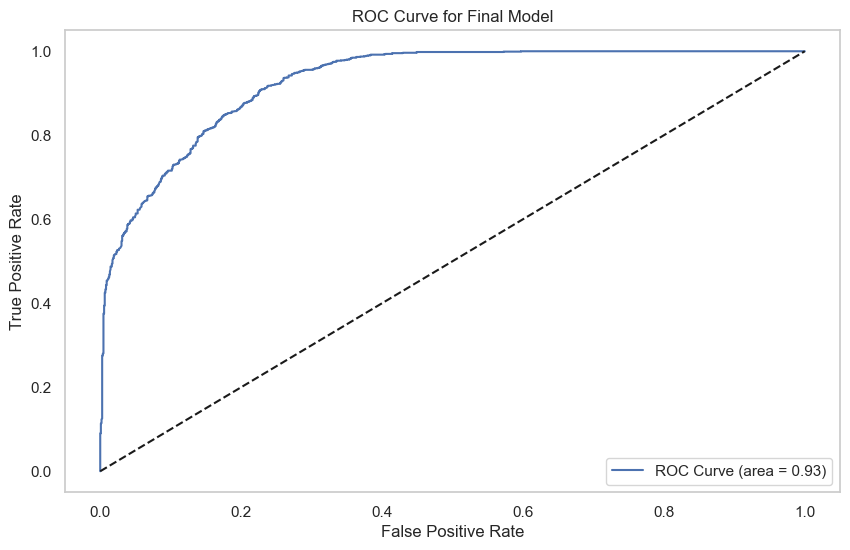

In [365]:
if y_pred_proba is not None:
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Final Model')
    plt.legend(loc="lower right")
    plt.grid(False)
    plt.show()

<a id='6.2'></a>
## 7.2. Variable Intuition/Feature Importance

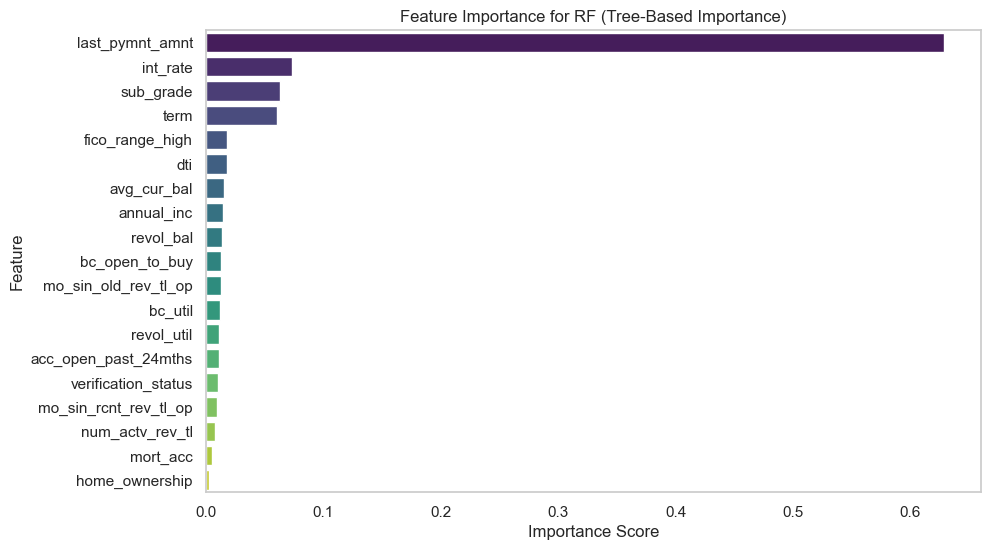

In [366]:
importances = final_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_indices = range(len(importances))

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette="viridis")
plt.title(f"Feature Importance for {model_name} (Tree-Based Importance)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(False)
plt.show()

Last_pymnt_amnt by far the most important feature. It is followed by int_rate, sub_grade and term.

These were the most correlated with our target from our previous analysies and they all make sense as good predictors.

# My Suggestions

What if the best model is **AdaBoost**? We will fine-tune its hyperparameters here to see if it can achieve better performance.

In [350]:
# Initialize the AdaBoost model
best_model_Ada = AdaBoostClassifier(random_state=42)

# Define the parameter grid for AdaBoost
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}

# Using Stratified K-Folds in GridSearchCV
stratified_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# GridSearchCV with AdaBoost
grid_search = GridSearchCV(estimator=best_model_Ada, param_grid=param_grid, cv=stratified_cv, scoring='roc_auc', n_jobs=-1, verbose=2, return_train_score=True)
grid_search.fit(X_train, y_train)

# Display the best parameters and best cross-validation score
print("Best Parameters:", grid_search.best_params_)
print("")
print("Best Cross-Validation Score:", grid_search.best_score_)


Fitting 10 folds for each of 16 candidates, totalling 160 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/ana

[CV] END ................learning_rate=0.01, n_estimators=50; total time=   0.8s
[CV] END ................learning_rate=0.01, n_estimators=50; total time=   0.8s
[CV] END ................learning_rate=0.01, n_estimators=50; total time=   0.8s
[CV] END ................learning_rate=0.01, n_estimators=50; total time=   0.7s
[CV] END ................learning_rate=0.01, n_estimators=50; total time=   0.7s
[CV] END ................learning_rate=0.01, n_estimators=50; total time=   0.7s
[CV] END ................learning_rate=0.01, n_estimators=50; total time=   0.7s
[CV] END ................learning_rate=0.01, n_estimators=50; total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/ana

[CV] END ................learning_rate=0.01, n_estimators=50; total time=   0.7s
[CV] END ................learning_rate=0.01, n_estimators=50; total time=   0.7s


...

[CV] END ................learning_rate=1.0, n_estimators=200; total time=   5.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[CV] END ................learning_rate=1.0, n_estimators=200; total time=   5.3s
[CV] END ................learning_rate=1.0, n_estimators=200; total time=   6.0s
[CV] END ................learning_rate=1.0, n_estimators=200; total time=   5.6s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[CV] END ................learning_rate=1.0, n_estimators=200; total time=   5.6s
[CV] END ................learning_rate=1.0, n_estimators=200; total time=   5.8s
[CV] END ................learning_rate=1.0, n_estimators=200; total time=   5.1s
[CV] END ................learning_rate=1.0, n_estimators=200; total time=   4.7s
[CV] END ................learning_rate=1.0, n_estimators=200; total time=   4.2s
[CV] END ................learning_rate=1.0, n_estimators=200; total time=   4.1s
Best Parameters: {'learning_rate': 0.1, 'n_estimators': 200}

Best Cross-Validation Score: 0.9266629179666401


In [367]:
# Best model with the optimal parameters found by GridSearchCV
final_model_ada = grid_search.best_estimator_

# Fitting the final model on the entire training data
final_model_ada.fit(X_train, y_train)

AdaBoostClassifier(learning_rate=0.1, n_estimators=200, random_state=42)

Final Model Test Accuracy: 0.8386363636363636

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.77      0.83      1092
           1       0.80      0.91      0.85      1108

    accuracy                           0.84      2200
   macro avg       0.85      0.84      0.84      2200
weighted avg       0.85      0.84      0.84      2200




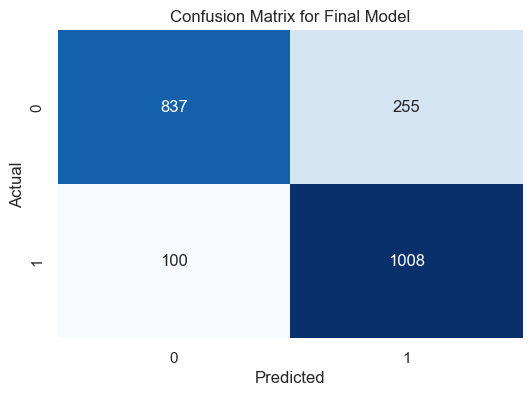

In [368]:
# Predicting on the test data
y_pred = final_model_ada.predict(X_test)
y_pred_proba = final_model_ada.predict_proba(X_test)[:, 1] if hasattr(final_model_ada, "predict_proba") else None


print("Final Model Test Accuracy:", accuracy_score(y_test, y_pred))
print("")

print("Classification Report:\n", classification_report(y_test, y_pred))

print("")
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix for Final Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

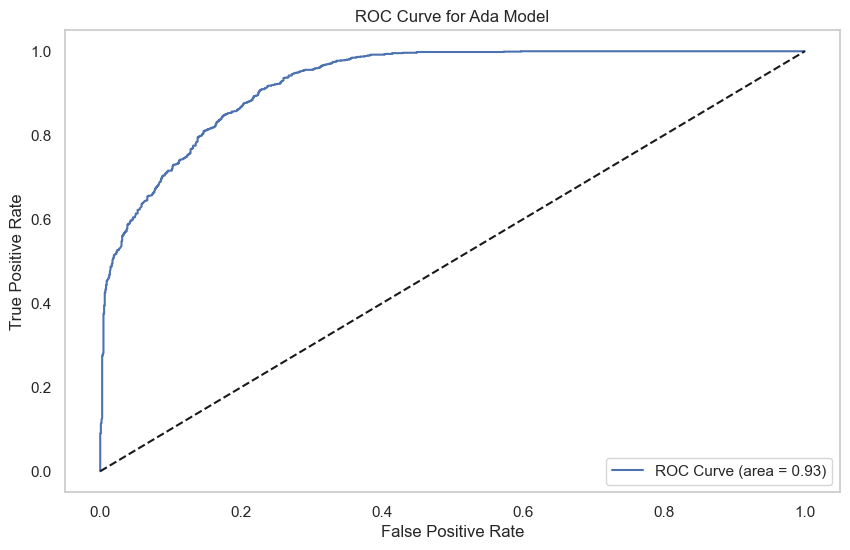

In [369]:
#ROC Curve
if y_pred_proba is not None:
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Ada Model')
    plt.legend(loc="lower right")
    plt.grid(False)
    plt.show()

**It is not better than Random Forest.**

Actually, it achieves similar results, but at a much higher traning speed. If one was willing to go deeper into tunning, working with AbaBoost might save a lot of time.

## Conclusion

The goal of this work is to develop a model capable of predicting whether a person will repay their loan. To accomplish this, we analyze our data to learn the differences between borrowers likely to end up in "charge-off" status (defaulting on the loan) and those who will fully repay.

To reach this objective, we experimented with various techniques and models. Ultimately, the best results came from a Random Forest model and an AdaBoost model. Since our AdaBoost implementation used a decision stump (a single-level decision tree) as a weak learner, a pattern emerged: algorithms based on decision trees seem particularly well-suited to this type of classification problem.

Our final model achieved a strong performance, with an Area Under the Curve (AUC) of 0.93 and an accuracy of 0.83. These metrics indicate good predictive power for this type of problem, particularly given the challenges of distinguishing between loan defaulters and non-defaulters.

In this context, we prioritize avoiding false negatives, where the positive class represents "charge-off" (defaulted loans) and the negative class represents "fully paid" loans. This means we aim to minimize instances where a borrower likely to default is predicted as likely to repay. Such errors are more costly to lenders than the alternative — mistakenly classifying a good borrower as a risk and potentially rejecting them. Given this trade-off, we are willing to sacrifice some ability to identify reliable borrowers if it helps us more effectively avoid those at higher risk of default.

The ROC curve is a powerful tool for optimizing this balance. Depending on the level of risk tolerance, we can select an appropriate decision threshold on the ROC curve to favor a lower false negative rate. This approach allows lenders to adjust their decision-making to align with their risk management goals, whether more conservative or aggressive.